# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mlt
import seaborn as sns
mlt.style.use('fivethirtyeight')
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as tls

# Load Dataset

In [3]:
matches = pd.read_csv('matches.csv')

In [4]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
delivery = pd.read_csv('deliveries.csv')

In [6]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


# Preprocessing

In [7]:
num_cols = delivery.select_dtypes(include=['number']).columns
delivery[num_cols] = delivery[num_cols].fillna(0)

In [8]:
matches['team1'].unique()

<StringArray>
['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

In [10]:
matches.replace(['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru'],

                ['RCB','KXIP','DD','MI','KKR','RR','DC','CSK','KTK','PW','SRH','GL','RPS','RPS','DEL C','PK','LSG','GT','RCB'],inplace = True)


delivery.replace(['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru'],

                ['RCB','KXIP','DD','MI','KKR','RR','DC','CSK','KTK','PW','SRH','GL','RPS','RPS','DEL C','PK','LSG','GT','RCB'],inplace = True)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,KKR,RCB,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,KKR,RCB,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,KKR,RCB,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,KKR,RCB,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,KKR,RCB,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260915,1426312,2,KKR,SRH,9,5,SS Iyer,AK Markram,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260916,1426312,2,KKR,SRH,9,6,VR Iyer,AK Markram,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260917,1426312,2,KKR,SRH,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,NaN,0,NaN,NaN,NaN
260918,1426312,2,KKR,SRH,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,0,1,NaN,0,NaN,NaN,NaN


In [11]:
print("Total Matches Played:", matches.shape[0])
print("\nVenues Played at:",matches['city'].unique())
print("\nTeams:", matches['team1'].unique())

Total Matches Played: 1095

Venues Played at: <StringArray>
[     'Bangalore',     'Chandigarh',          'Delhi',         'Mumbai',
        'Kolkata',         'Jaipur',      'Hyderabad',        'Chennai',
      'Cape Town', 'Port Elizabeth',         'Durban',      'Centurion',
    'East London',   'Johannesburg',      'Kimberley',   'Bloemfontein',
      'Ahmedabad',        'Cuttack',         'Nagpur',     'Dharamsala',
          'Kochi',         'Indore',  'Visakhapatnam',           'Pune',
         'Raipur',         'Ranchi',      'Abu Dhabi',              nan,
         'Rajkot',         'Kanpur',      'Bengaluru',          'Dubai',
        'Sharjah',    'Navi Mumbai',        'Lucknow',       'Guwahati',
         'Mohali']
Length: 37, dtype: str

Teams: <StringArray>
[  'RCB',  'KXIP',    'DD',    'MI',   'KKR',    'RR',    'DC',   'CSK',
   'KTK',    'PW',   'SRH',    'GL',   'RPS', 'DEL C',    'PK',   'LSG',
    'GT']
Length: 17, dtype: str


In [12]:
print("\nTotal Venues Played:", matches['city'].nunique())
print("\nTotal umpires:", matches['umpire1'].nunique())


Total Venues Played: 36

Total umpires: 62


In [13]:
print(matches['player_of_match'].value_counts().idxmax(), ": has the most number of man of the match award")

print(matches['winner'].value_counts().idxmax(), ": has the highest number of match wins")

AB de Villiers : has the most number of man of the match award
MI : has the highest number of match wins


In [14]:
df = matches.iloc[[matches['result_margin'].idxmax()]]
df = [['season','team1','team2','winner','result_margin']]

In [15]:
print("toss decisions in %\n", ((matches['toss_decision']).value_counts(normalize = True))*100)

toss decisions in %
 toss_decision
field    64.292237
bat      35.707763
Name: proportion, dtype: float64


# Winner prediction by year

In [16]:
season_wins = (
    matches.groupby(['season', 'winner'])
    .size()
    .reset_index(name='wins')
)

winner_by_year = season_wins.loc[
    season_wins.groupby('season')['wins'].idxmax()
].sort_values('season')

print(winner_by_year)

      season winner  wins
7    2007/08     RR    13
10      2009     DD    10
21   2009/10     MI    11
24      2011    CSK    11
37      2012    KKR    12
47      2013     MI    13
55      2014   KXIP    12
60      2015    CSK    10
75      2016    SRH    11
80      2017     MI    12
84      2018    CSK    11
96      2019     MI    11
104  2020/21     MI    11
108     2021    CSK    11
118     2022     GT    12
128     2023     GT    11
139     2024    KKR    11


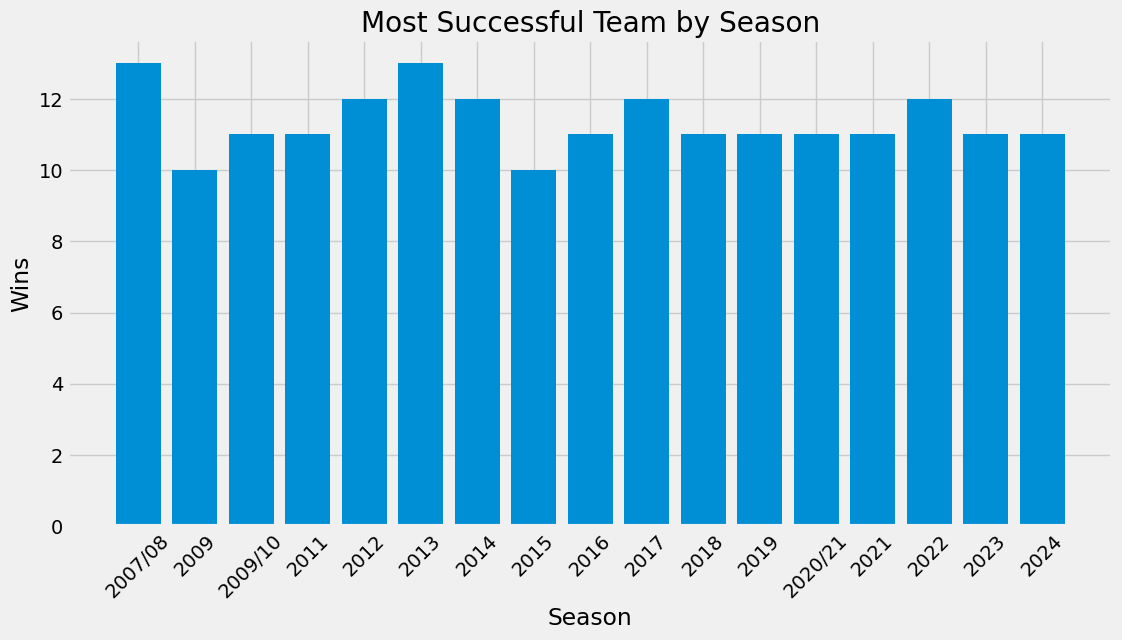

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(winner_by_year['season'], winner_by_year['wins'])
plt.xticks(rotation=45)
plt.title("Most Successful Team by Season")
plt.xlabel("Season")
plt.ylabel("Wins")
plt.show()


# Super over analysis

In [18]:
super_over_matches = matches[matches['super_over'] == 'Y']

print("Total Super Over Matches:", super_over_matches.shape[0])

teams_involved = pd.concat([
    super_over_matches['team1'],
    super_over_matches['team2']
]).value_counts()

print("\nTeams involved in Super Overs:")
print(teams_involved)

super_over_winners = super_over_matches['winner'].value_counts()

print("\nSuper Over Winners:")
print(super_over_winners)


Total Super Over Matches: 14

Teams involved in Super Overs:
KKR      4
SRH      4
MI       4
KXIP     4
RCB      3
RR       3
DEL C    3
CSK      1
GL       1
DD       1
Name: count, dtype: int64

Super Over Winners:
winner
KXIP     3
DEL C    3
RR       2
RCB      2
MI       2
SRH      1
KKR      1
Name: count, dtype: int64


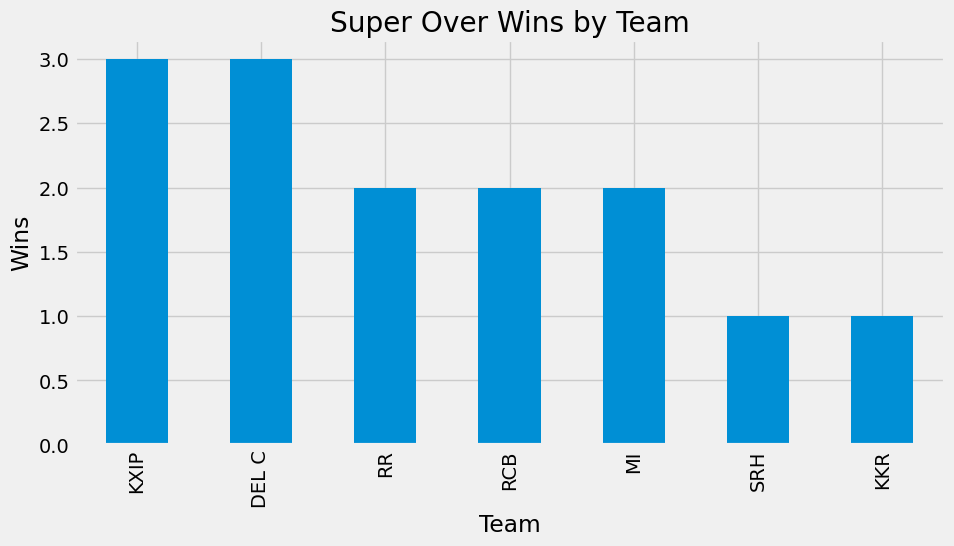

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
super_over_winners.plot(kind='bar')
plt.title("Super Over Wins by Team")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.show()


# Favorite umpire trends

In [29]:
umpires = pd.concat([matches['umpire1'], matches['umpire2']])

umpire_counts = umpires.value_counts().reset_index()
umpire_counts.columns = ['umpire', 'matches']

top_umpires = umpire_counts.head(10)

print(top_umpires)


                  umpire  matches
0                 S Ravi      131
1           AK Chaudhary      131
2            Nitin Menon      104
3        HDPK Dharmasena       98
4          C Shamshuddin       88
5            CB Gaffaney       77
6  KN Ananthapadmanabhan       72
7              M Erasmus       67
8              VK Sharma       65
9           BNJ Oxenford       64


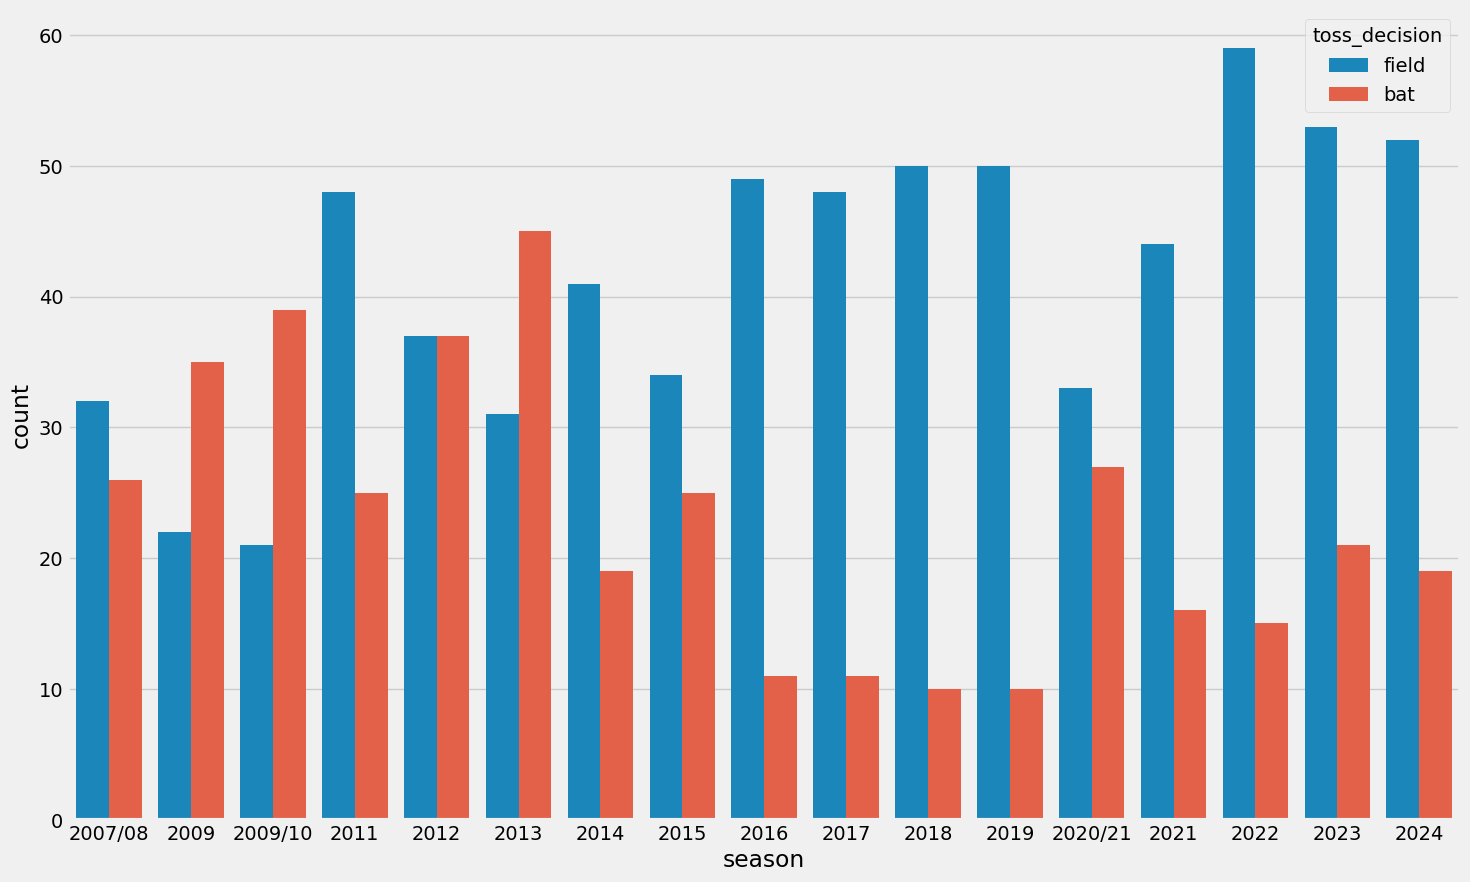

In [30]:
mlt.subplots(figsize = (16, 10))
sns.countplot(x = 'season', hue = 'toss_decision', data = matches)
mlt.show()

# High-scoring matches (200+ runs)



In [32]:
team_scores = (
    delivery.groupby(['match_id', 'batting_team'])['total_runs']
    .sum()
    .reset_index()
)

high_scores = team_scores[team_scores['total_runs'] >= 200]

print("200+ Run Innings:")
print(high_scores.head())

team_200_counts = high_scores['batting_team'].value_counts()

print("\nTeams with most 200+ totals:")
print(team_200_counts)


200+ Run Innings:
    match_id batting_team  total_runs
0     335982          KKR         222
2     335983          CSK         240
3     335983         KXIP         207
14    335989          CSK         208
15    335989           MI         202

Teams with most 200+ totals:
batting_team
CSK      32
RCB      30
KKR      25
MI       25
RR       21
SRH      21
KXIP     15
DEL C    11
PK       10
GT        8
LSG       7
DD        5
DC        1
GL        1
Name: count, dtype: int64


# Toss Wins by Team in IPL

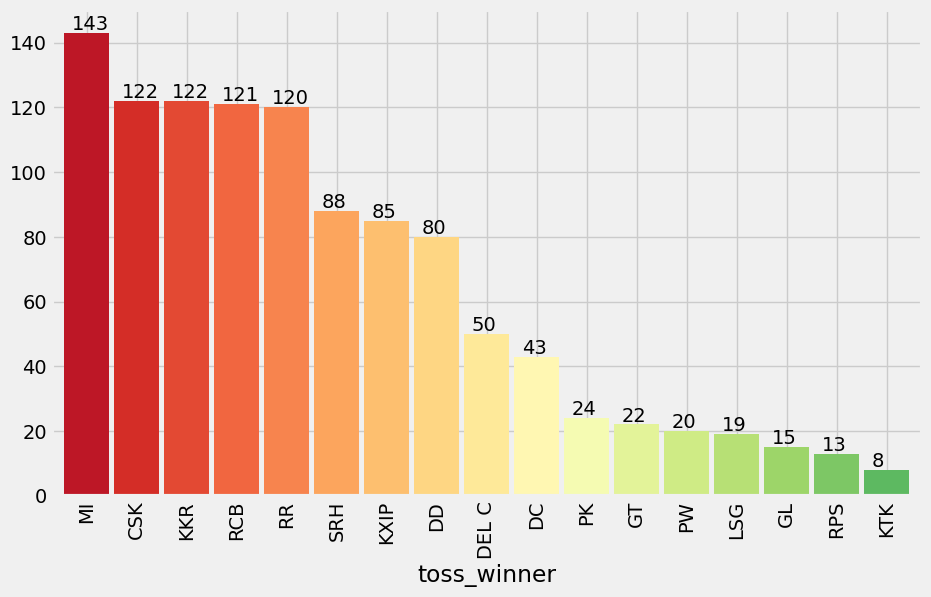

In [33]:
mlt.subplots(figsize = (10, 6))

ax = matches['toss_winner'].value_counts().plot.bar(width = 0.9, color = sns.color_palette('RdYlGn', 20))

for p in ax.patches:
    ax.annotate(format(p.get_height()), (p.get_x() + 0.15, p.get_height() + 1))

mlt.show()

# Team-wise Matches Played vs Matches Won in IPL

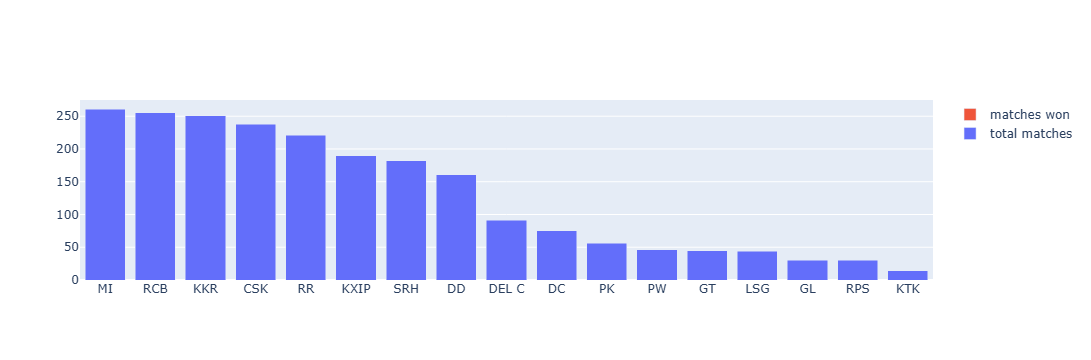

In [34]:
matches_played_byteams = pd.concat([matches['team1'], matches['team2']])

matches_played_byteams = matches_played_byteams.value_counts().reset_index()

matches_played_byteams.columns = ['teams', 'total matches']

matches_played_byteams['wins'] = matches['winner'].value_counts().reset_index()['winner']

matches_played_byteams.set_index('teams', inplace = True)

trace1 = go.Bar(
    x=matches_played_byteams.index,
    y=matches_played_byteams['total matches'],
    name='total matches'
)

trace2 = go.Bar(
    x=matches_played_byteams.index,
    y=matches_played_byteams['wins'],
    name='matches won'
)

data = [trace1, trace2]
layout = go.Layout(
    barmode='stack'
)

fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='stacked-bar')

# Total Matches vs Matches Won by Teams

       total matches  wins
teams                     
MI               261   144
RCB              255   123
KKR              251   131
CSK              238   138
RR               221   112
KXIP             190    88
SRH              182    88
DD               161    67
DEL C             91    48
DC                75    29
PK                56    24
PW                46    12
GT                45    28
LSG               44    24
GL                30    13
RPS               30    15
KTK               14     6


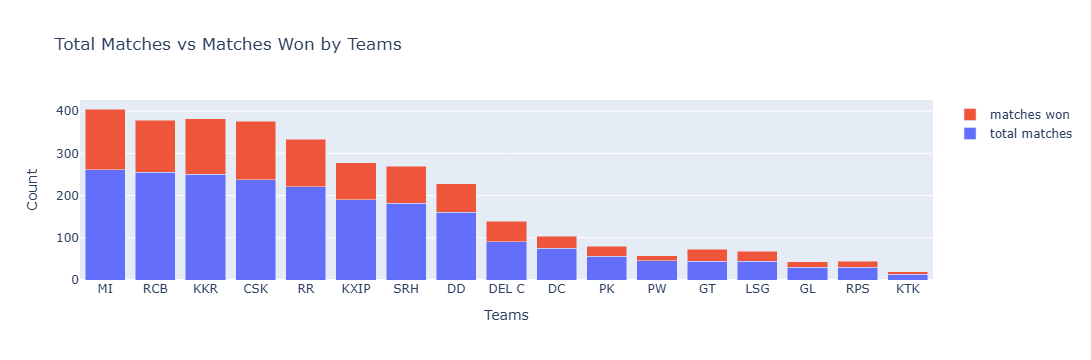

In [35]:
py.init_notebook_mode(connected=True)

matches_played_byteams = pd.concat([matches['team1'], matches['team2']])

matches_played_byteams = matches_played_byteams.value_counts().reset_index()
matches_played_byteams.columns = ['teams', 'total matches']

wins = matches['winner'].value_counts().reset_index()
wins.columns = ['teams', 'wins']

matches_played_byteams = matches_played_byteams.merge(wins, on='teams', how='left')
matches_played_byteams['wins'] = matches_played_byteams['wins'].fillna(0)

matches_played_byteams.set_index('teams', inplace = True)

print(matches_played_byteams)

trace1 = go.Bar(
    x=matches_played_byteams.index,
    y=matches_played_byteams['total matches'],
    name='total matches'
)

trace2 = go.Bar(
    x=matches_played_byteams.index,
    y=matches_played_byteams['wins'],
    name='matches won'
)

data = [trace1, trace2]
layout = go.Layout(
    title='Total Matches vs Matches Won by Teams',
    xaxis=dict(title='Teams'),
    yaxis=dict(title='Count'),
    barmode='stack'
)

fig = go.Figure(data=data, layout=layout)
py.iplot(fig, filename='stacked-bar')

# Impact of Toss Winning on Match Outcome in IPL

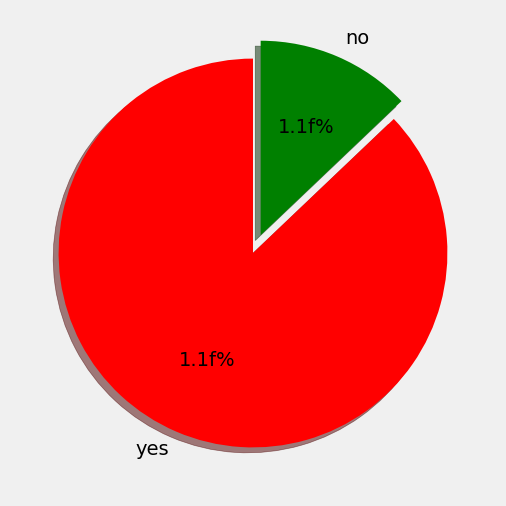

In [36]:
df = matches[matches['toss_winner'] == matches['winner']]

slices = [len(df), (636 - len(df))]

labels = ['yes', 'no']

mlt.pie(slices, labels = labels,
       startangle = 90,
       shadow = True,
       explode = (0, 0.1),
       autopct = "1.1f%%",
       colors = ['r', 'g'])

fig = mlt.gcf()

fig.set_size_inches(6, 6)

mlt.show()

# Total Runs Across the Seasons

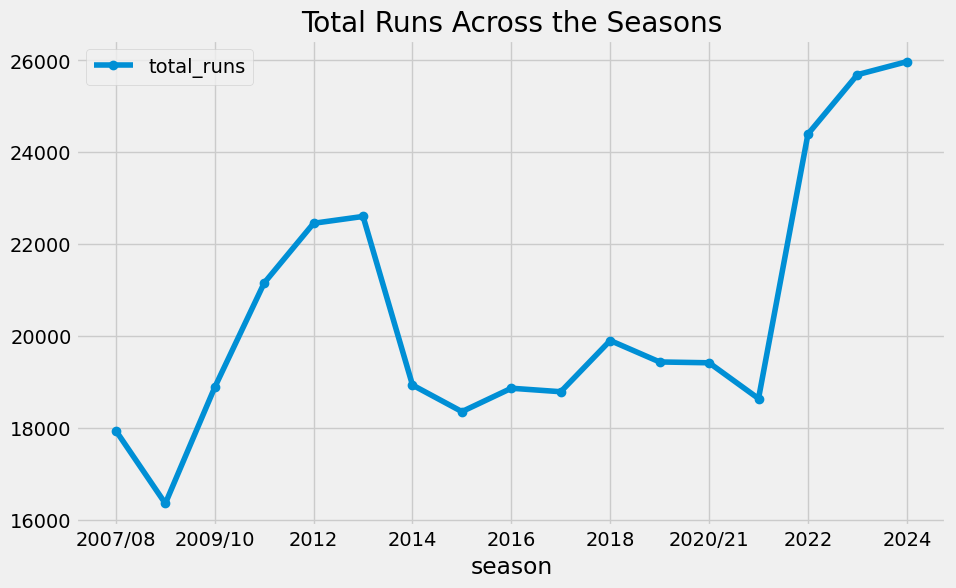

In [38]:
batsmen = matches[['id', 'season']].merge(delivery,
                                         left_on = 'id',
                                         right_on = 'match_id',
                                         how = 'left').drop('id', axis = 1)

season = batsmen.groupby(['season'])['total_runs'].sum().reset_index()

season.set_index('season').plot(marker = 'o')

mlt.gcf().set_size_inches(10, 6)

mlt.title("Total Runs Across the Seasons")

mlt.show()

# Season-wise Boundaries in IPL (Fours vs Sixes)

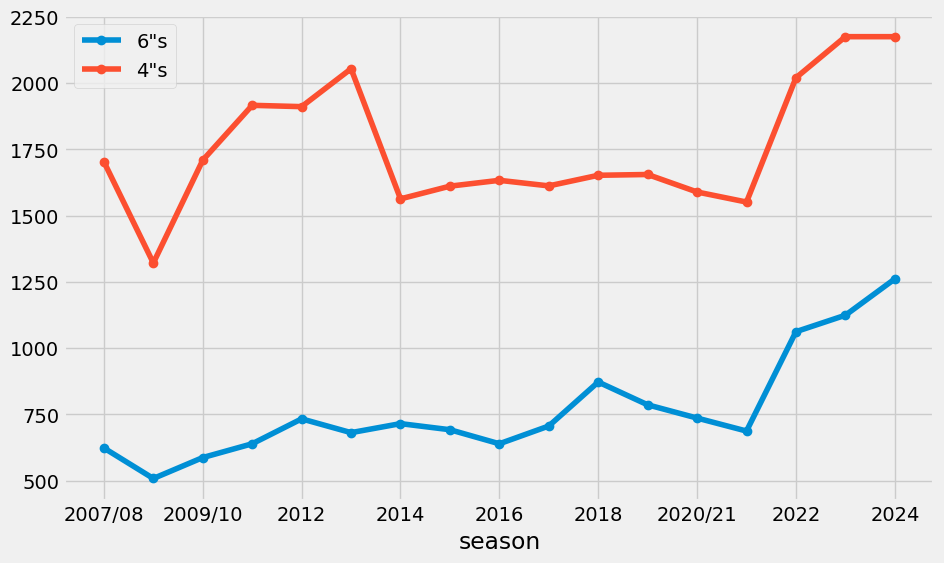

In [39]:
season_boundaries = batsmen.groupby("season")['batsman_runs'].agg(lambda x: (x == 6).sum()).reset_index()

a = batsmen.groupby("season")['batsman_runs'].agg(lambda x: (x == 4).sum()).reset_index()

season_boundaries = season_boundaries.merge(a, left_on = 'season', right_on = 'season', how = 'left')

season_boundaries = season_boundaries.rename(columns={'batsman_runs_x':'6"s', 'batsman_runs_y':'4"s'})

season_boundaries.set_index('season')[['6"s','4"s']].plot(marker='o')

fig = mlt.gcf()

fig.set_size_inches(10, 6)

mlt.show()


# Run Scoring Pattern by Over for IPL Teams (Teams with 50+ Matches)

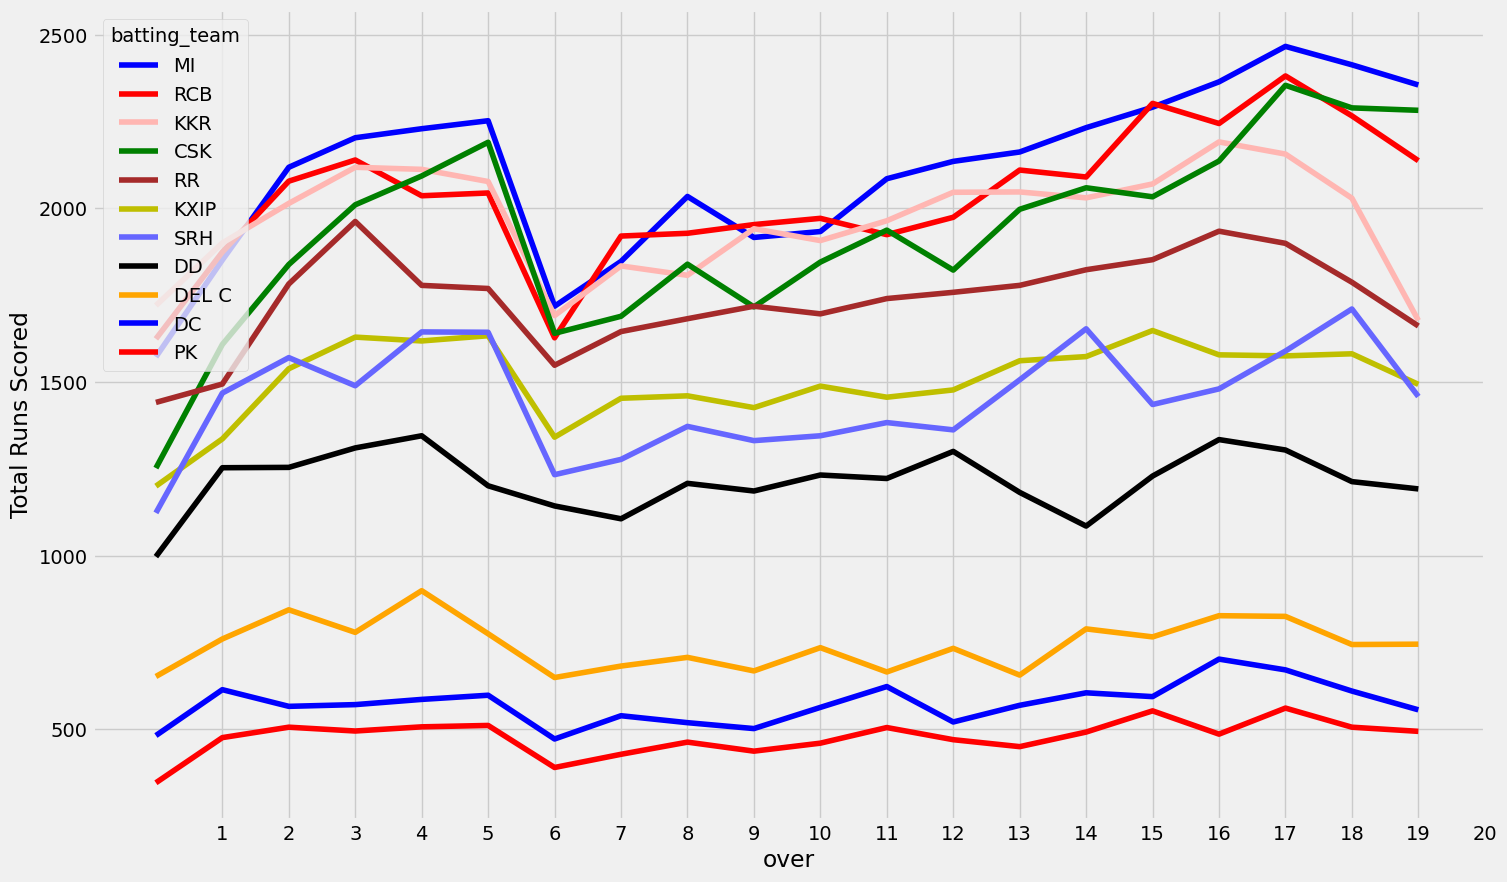

In [40]:
runs_per_over = delivery.pivot_table(index = ['over'], columns = 'batting_team',
                                    values = 'total_runs',
                                    aggfunc = sum)

runs_per_over[(matches_played_byteams[matches_played_byteams['total matches'] > 50].index)].plot(color = ['b', 'r', "#Ffb6b2", "g", 'brown', 'y','#6666ff','black','#FFA500'])

x=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]

mlt.xticks(x)

mlt.ylabel('Total Runs Scored')

fig = mlt.gcf()

fig.set_size_inches(16, 10)

mlt.show()

# Orange & Purple Cap winners by season

In [43]:
df = delivery.merge(
    matches[['id', 'season']],
    left_on='match_id',
    right_on='id',
    how='left'
)


### Orange Cap Winners (Highest Runs per Season)

In [44]:
season_runs = df.groupby(['season', 'batter'])['batsman_runs'] \
                .sum().reset_index()

orange_cap = season_runs.loc[
    season_runs.groupby('season')['batsman_runs'].idxmax()
].sort_values('season')

orange_cap = orange_cap.rename(columns={
    'batter': 'Orange Cap Winner',
    'batsman_runs': 'Runs'
})

print("Orange Cap Winners by Season:")
print(orange_cap)


Orange Cap Winners by Season:
       season Orange Cap Winner  Runs
115   2007/08          SE Marsh   616
229      2009         ML Hayden   572
446   2009/10      SR Tendulkar   618
502      2011          CH Gayle   608
684      2012          CH Gayle   733
910      2013        MEK Hussey   733
1088     2014        RV Uthappa   660
1148     2015         DA Warner   562
1383     2016           V Kohli   973
1422     2017         DA Warner   641
1594     2018     KS Williamson   735
1694     2019         DA Warner   692
1866  2020/21          KL Rahul   676
2051     2021        RD Gaikwad   635
2144     2022        JC Buttler   863
2423     2023      Shubman Gill   890
2606     2024           V Kohli   741


### Purple Cap Winners (Highest Wickets per Season)

In [45]:
wickets = df[
    (df['is_wicket'] == 1) &
    (df['dismissal_kind'] != 'run out')
]

season_wickets = wickets.groupby(['season', 'bowler']) \
                        .size().reset_index(name='wickets')

purple_cap = season_wickets.loc[
    season_wickets.groupby('season')['wickets'].idxmax()
].sort_values('season')

purple_cap = purple_cap.rename(columns={
    'bowler': 'Purple Cap Winner'
})

print("\nPurple Cap Winners by Season:")
print(purple_cap)



Purple Cap Winners by Season:
       season Purple Cap Winner  wickets
75    2007/08     Sohail Tanvir       22
152      2009          RP Singh       23
241   2009/10           PP Ojha       21
367      2011        SL Malinga       28
437      2012          M Morkel       25
509      2013          DJ Bravo       32
638      2014         MM Sharma       23
694      2015          DJ Bravo       26
773      2016           B Kumar       23
860      2017           B Kumar       26
942      2018            AJ Tye       24
1048     2019       Imran Tahir       26
1141  2020/21          K Rabada       32
1211     2021          HV Patel       32
1379     2022         YS Chahal       27
1448     2023    Mohammed Shami       28
1516     2024          HV Patel       24


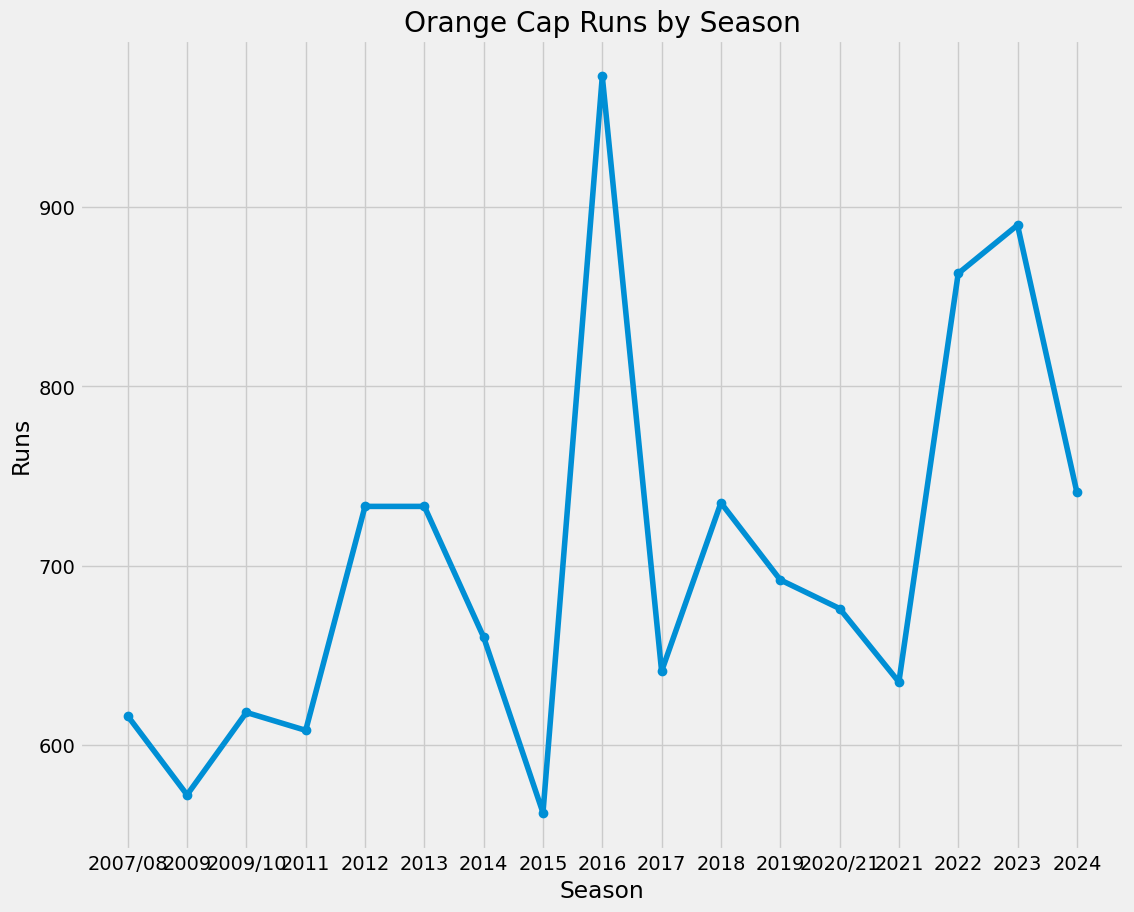

In [47]:
plt.figure(figsize=(12,10))
plt.plot(orange_cap['season'], orange_cap['Runs'], marker='o')
plt.title("Orange Cap Runs by Season")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.show()
